<a href="https://colab.research.google.com/github/Doeun0913/study/blob/feat%2Fmonster/4_3_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2. 라이브러리 및 데이터 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_url = 'https://media.githubusercontent.com/media/musthave-ML10/data_source/main/salary.csv'
data = pd.read_csv(file_url, skipinitialspace = True)

In [ ]:
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
# class 고윳값 확인하기
data['class'].unique()

array(['<=50K', '>50K'], dtype=object)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   education       48842 non-null  object
 3   education-num   48842 non-null  int64 
 4   marital-status  48842 non-null  object
 5   occupation      46033 non-null  object
 6   relationship    48842 non-null  object
 7   race            48842 non-null  object
 8   sex             48842 non-null  object
 9   capital-gain    48842 non-null  int64 
 10  capital-loss    48842 non-null  int64 
 11  hours-per-week  48842 non-null  int64 
 12  native-country  47985 non-null  object
 13  class           48842 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


In [ ]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
data.describe(include='all')

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
count,48842.000000,46043,48842,48842.000000,48842,46033,48842,48842,48842,48842.000000,48842.000000,48842.000000,47985,48842
unique,NaN,8,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,37155
mean,38.643585,NaN,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


## 3.1. 전처리: 범주형 데이터

In [ ]:
data['class'] = data['class'].map({'<=50K': 0, '>50K': 1})
data['class']

,class
0,0
1,0
2,1
3,1
4,0
...,...
48837,0
48838,1
48839,0
48840,0


In [ ]:
# object형 변수를 따로 리스트에 저장
obj_list = []
for i in data.columns:
  if data[i].dtype == 'object':
    obj_list.append(i)

obj_list

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [ ]:
# 각 변수의 고윳값 개수 확인
for i in obj_list:
  print(i, data[i].nunique())

workclass 8
education 16
marital-status 7
occupation 14
relationship 6
race 5
sex 2
native-country 41


In [ ]:
# education-num 과 education 변수와의 관계
for i in np.sort(data['education-num'].unique()):
  print(i, data[data['education-num'] == i]['education'].unique())

1 ['Preschool']
2 ['1st-4th']
3 ['5th-6th']
4 ['7th-8th']
5 ['9th']
6 ['10th']
7 ['11th']
8 ['12th']
9 ['HS-grad']
10 ['Some-college']
11 ['Assoc-voc']
12 ['Assoc-acdm']
13 ['Bachelors']
14 ['Masters']
15 ['Prof-school']
16 ['Doctorate']


In [ ]:
# education 변수 제거
data.drop('education', axis=1, inplace=True)

In [ ]:
# occupation 변수 처리
data['occupation'].value_counts()

,count
occupation,
Prof-specialty,6172
Craft-repair,6112
Exec-managerial,6086
Adm-clerical,5611
Sales,5504
Other-service,4923
Machine-op-inspct,3022
Transport-moving,2355
Handlers-cleaners,2072


In [ ]:
# native-country 변수 처리
data['native-country'].value_counts()

,count
native-country,
United-States,43832
Mexico,951
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151
Cuba,138


In [ ]:
# 나라별 class 평균 값 확인
data.groupby('native-country').mean(numeric_only=True).sort_values('class')

,age,education-num,capital-gain,capital-loss,hours-per-week,class
native-country,,,,,,
Holand-Netherlands,32.000000,10.000000,0.000000,2205.000000,40.000000,0.000000
Guatemala,32.090909,6.306818,167.875000,18.113636,38.715909,0.034091
Outlying-US(Guam-USVI-etc),38.826087,10.043478,0.000000,76.608696,41.347826,0.043478
Columbia,39.458824,9.258824,125.364706,65.247059,39.929412,0.047059
Dominican-Republic,37.970874,7.320388,1064.456311,39.029126,41.621359,0.048544
Mexico,33.635121,6.026288,415.954784,32.656151,40.213460,0.049422
Nicaragua,36.285714,9.000000,138.653061,69.938776,36.938776,0.061224
El-Salvador,33.380645,6.722581,392.761290,36.367742,36.361290,0.070968
Trinadad&Tobago,39.259259,8.962963,116.185185,156.518519,38.888889,0.074074


In [ ]:
# native-country(범주형)를 국가별 class 평균(숫자)로 치환
data['native-country'] = data['native-country'].map(
    data.groupby('native-country')['class'].mean()
)
data

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,0.243977,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,0.243977,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,0.243977,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,0.243977,1
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,30,0.243977,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,0.243977,0
48838,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,0.243977,1
48839,58,Private,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,0.243977,0
48840,22,Private,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,0.243977,0


In [ ]:
data.tail(30)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
48812,30,NaN,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,0.243977,0
48813,34,Private,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,60,0.243977,1
48814,54,Private,13,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,0,0,50,0.347826,1
48815,37,Private,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,39,0.243977,0
48816,22,Private,8,Never-married,Protective-serv,Own-child,Black,Male,0,0,35,0.243977,0
48817,34,Private,13,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,55,0.243977,1
48818,30,Private,9,Never-married,Craft-repair,Not-in-family,Black,Male,0,0,46,0.243977,0
48819,38,Private,13,Divorced,Prof-specialty,Unmarried,Black,Female,15020,0,45,0.243977,1
48820,71,NaN,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,0.243977,1
48821,45,State-gov,9,Separated,Adm-clerical,Own-child,White,Female,0,0,40,0.243977,0


## 3.2. 전처리: 결측치 처리 및 더비 변수 변환

### 3.2.1 결측치 처리

In [ ]:
data.isna().mean()

,0
age,0.000000
workclass,0.057307
education-num,0.000000
marital-status,0.000000
occupation,0.057512
relationship,0.000000
race,0.000000
sex,0.000000
capital-gain,0.000000
capital-loss,0.000000


In [ ]:
# native-country 결측치 처리
data['native-country'] = data['native-country'].fillna(-99)

In [ ]:
# workclass 고윳값 빈도 확인
data['workclass'].value_counts()

,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


In [ ]:
# 'Private'으로 결측치 채우기
data['workclass'] = data['workclass'].fillna('Private')

In [ ]:
# occupation 고윳값 빈도 확인
data['occupation'].value_counts()

,count
occupation,
Prof-specialty,6172
Craft-repair,6112
Exec-managerial,6086
Adm-clerical,5611
Sales,5504
Other-service,4923
Machine-op-inspct,3022
Transport-moving,2355
Handlers-cleaners,2072


In [ ]:
data['occupation'] = data['occupation'].fillna('Unknown')

### 3.2.2 나머지 모든 범주형 변수를 더미 변수로 변환

In [ ]:
data = pd.get_dummies(data, drop_first=True)

In [ ]:
data.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,native-country,class,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male
0,25,7,0,0,40,0.243977,0,False,False,True,...,False,False,True,False,False,False,True,False,False,True
1,38,9,0,0,50,0.243977,0,False,False,True,...,False,False,False,False,False,False,False,False,True,True
2,28,12,0,0,40,0.243977,1,True,False,False,...,False,False,False,False,False,False,False,False,True,True
3,44,10,7688,0,40,0.243977,1,False,False,True,...,False,False,False,False,False,False,True,False,False,True
4,18,10,0,0,30,0.243977,0,False,False,True,...,False,False,True,False,False,False,False,False,True,False


In [ ]:
data.columns # class까지는 숫자 변수, 그 밖의 변수는 더미 변수로 변수 ++

Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'class', 'workclass_Local-gov',
       'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_Without-pay', 'marital-status_Married-AF-spouse',
       'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct',
       'occupation_Other-service', 'occupation_Priv-house-serv',
       'occupation_Prof-specialty', 'occupation_Protective-serv',
       'occupation_Sales', 'occupation_Tech-support',
       'occupation_Transport-moving', 'occupation_Unknown',
       'relationship_Not-i

## 4. 모델링 및 평가하기

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.drop('class', axis=1), data['class'], test_size=0.4, random_state=100)

# X = data.drop('class', axis=1)
# y = data['class']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=100)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [ ]:
pred

array([1, 0, 0, ..., 1, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)

0.8154271382504991

## 7. 매개변수 튜닝

In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
print("Train score:", accuracy_score(y_train, train_pred), end=' ')
print("Test score:", accuracy_score(y_test, test_pred))

Train score: 0.9780242279474493 Test score: 0.8153759533193428


In [ ]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
print("Train score:", accuracy_score(y_train, train_pred), end=' ')
print("Test score:", accuracy_score(y_test, test_pred))

Train score: 0.8540180856509129 Test score: 0.8499769667809797


In [ ]:
model = DecisionTreeClassifier(max_depth=7)
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
print("Train score:", accuracy_score(y_train, train_pred), end=' ')
print("Test score:", accuracy_score(y_test, test_pred))

Train score: 0.8598532673605187 Test score: 0.8542765009981061


## 8. 트리 그래프

[Text(0.5034965034965035, 0.9375, 'x[14] <= 0.5\ngini = 0.363\nsamples = 29305\nvalue = [22330, 6975]'),
 Text(0.25655594405594406, 0.8125, 'x[2] <= 7055.5\ngini = 0.12\nsamples = 15888\nvalue = [14871, 1017]'),
 Text(0.3800262237762238, 0.875, 'True  '),
 Text(0.16695804195804195, 0.6875, 'x[1] <= 12.5\ngini = 0.092\nsamples = 15616\nvalue = [14863, 753]'),
 Text(0.09090909090909091, 0.5625, 'x[3] <= 2391.5\ngini = 0.048\nsamples = 12544\nvalue = [12233, 311]'),
 Text(0.055944055944055944, 0.4375, 'x[4] <= 40.5\ngini = 0.046\nsamples = 12517\nvalue = [12224, 293]'),
 Text(0.027972027972027972, 0.3125, 'x[0] <= 32.5\ngini = 0.029\nsamples = 10300\nvalue = [10149, 151]'),
 Text(0.013986013986013986, 0.1875, 'x[3] <= 2218.0\ngini = 0.008\nsamples = 5944\nvalue = [5920, 24]'),
 Text(0.006993006993006993, 0.0625, 'gini = 0.007\nsamples = 5938\nvalue = [5916, 22]'),
 Text(0.02097902097902098, 0.0625, 'gini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.04195804195804196, 0.1875, 'x[27] <= 

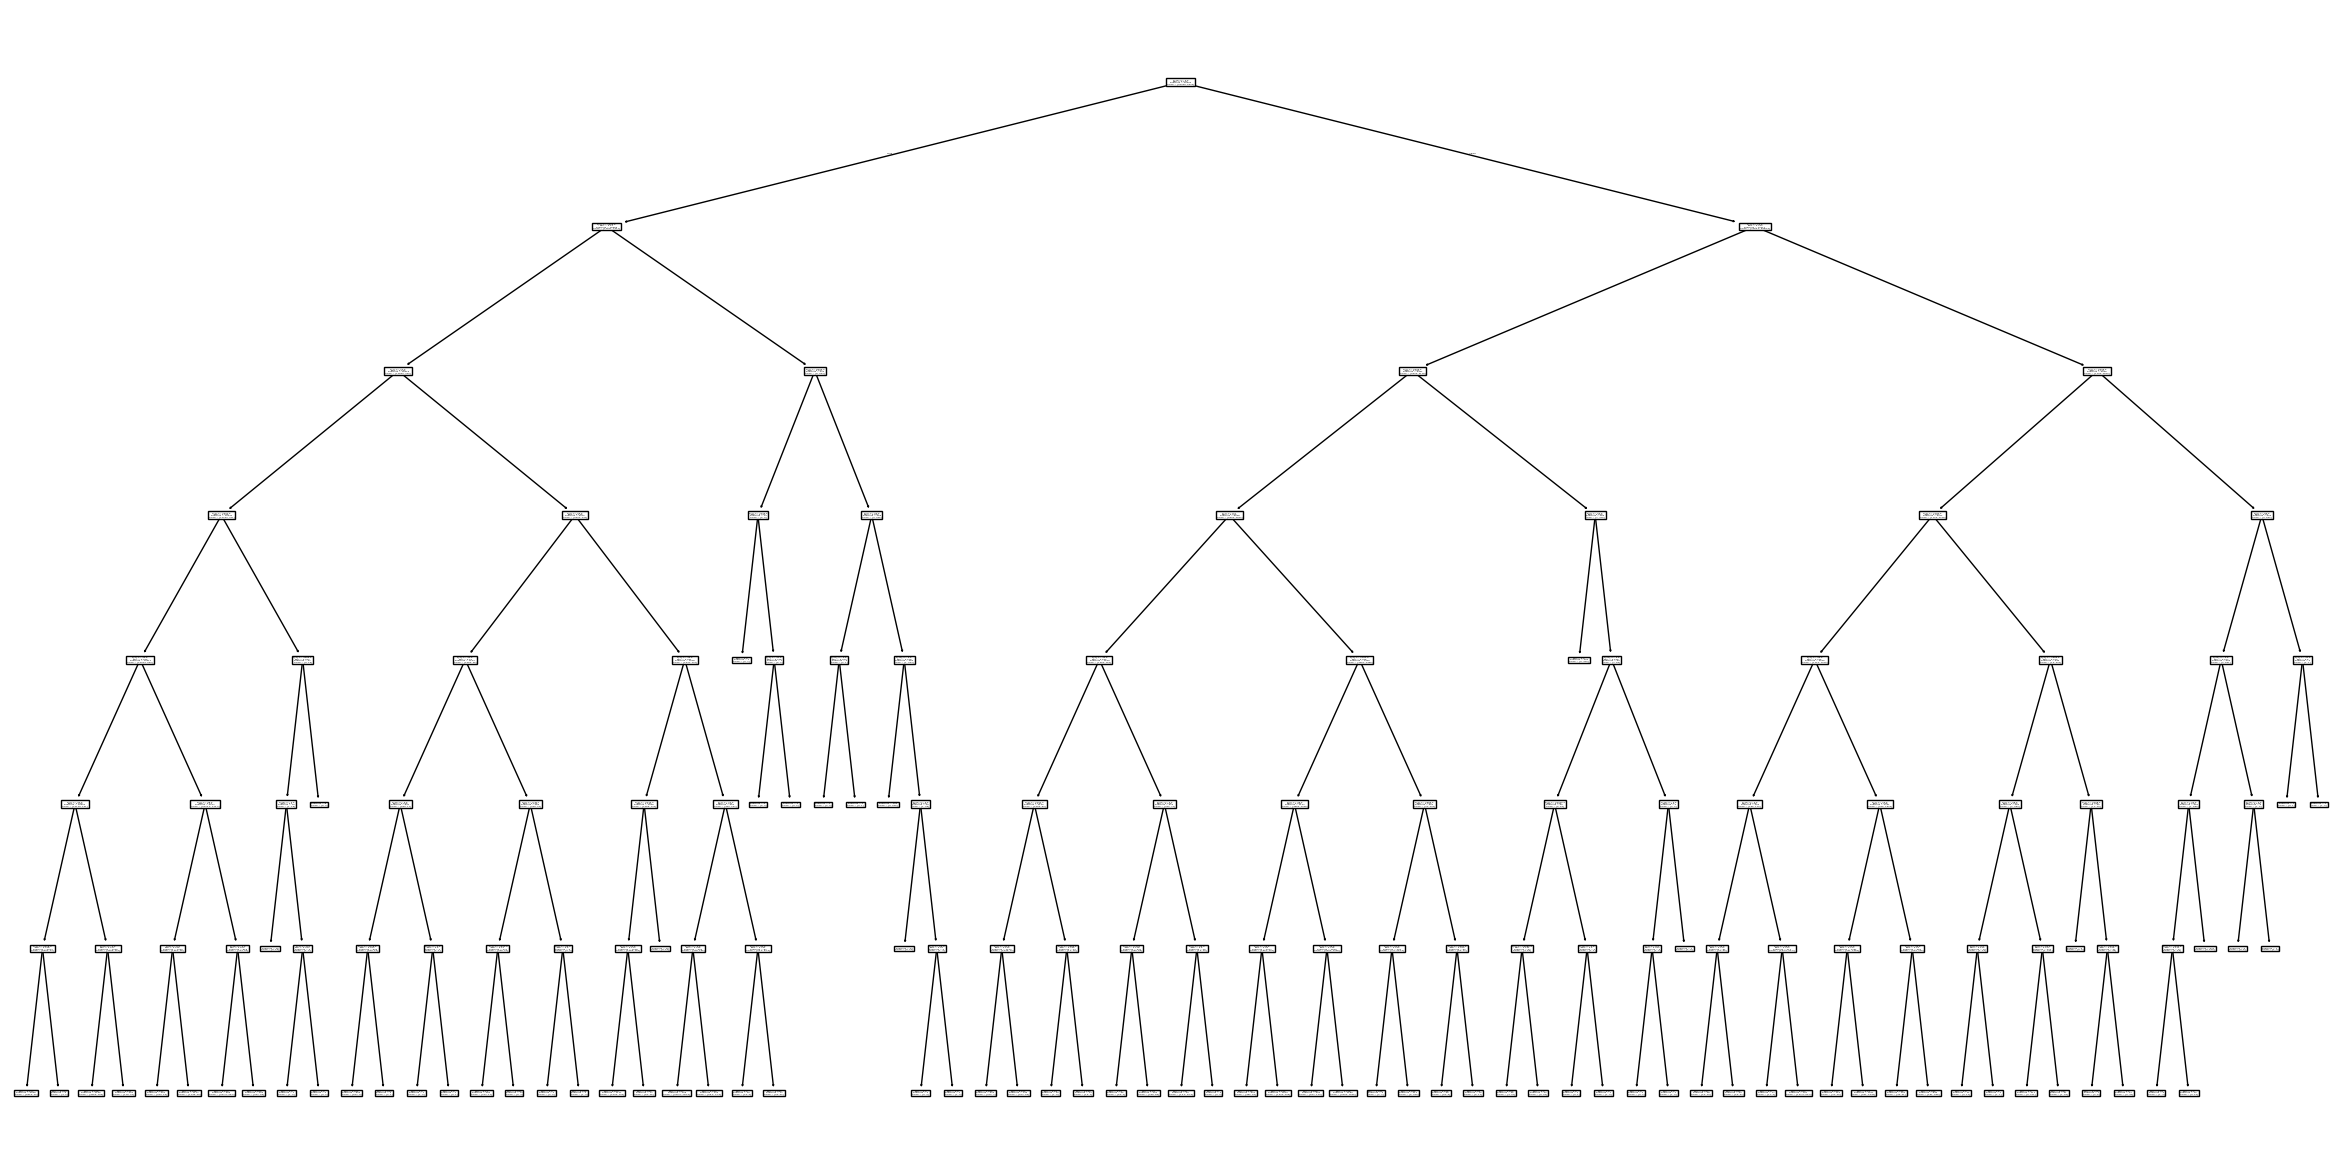

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(30, 15))
plot_tree(model)

[Text(0.5, 0.9, 'marital-status_Married-civ-spouse <= 0.5\ngini = 0.363\nsamples = 29305\nvalue = [22330, 6975]'),
 Text(0.25, 0.7, 'capital-gain <= 7055.5\ngini = 0.12\nsamples = 15888\nvalue = [14871, 1017]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'education-num <= 12.5\ngini = 0.092\nsamples = 15616\nvalue = [14863, 753]'),
 Text(0.0625, 0.3, 'capital-loss <= 2391.5\ngini = 0.048\nsamples = 12544\nvalue = [12233, 311]'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'age <= 29.5\ngini = 0.246\nsamples = 3072\nvalue = [2630, 442]'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'capital-gain <= 8296.0\ngini = 0.057\nsamples = 272\nvalue = [8, 264]'),
 Text(0.3125, 0.3, 'capital-gain <= 7436.5\ngini = 0.459\nsamples = 14\nvalue = [5, 9]'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 'age <= 20.5\ngini = 0.023\nsamples = 258\nvalue

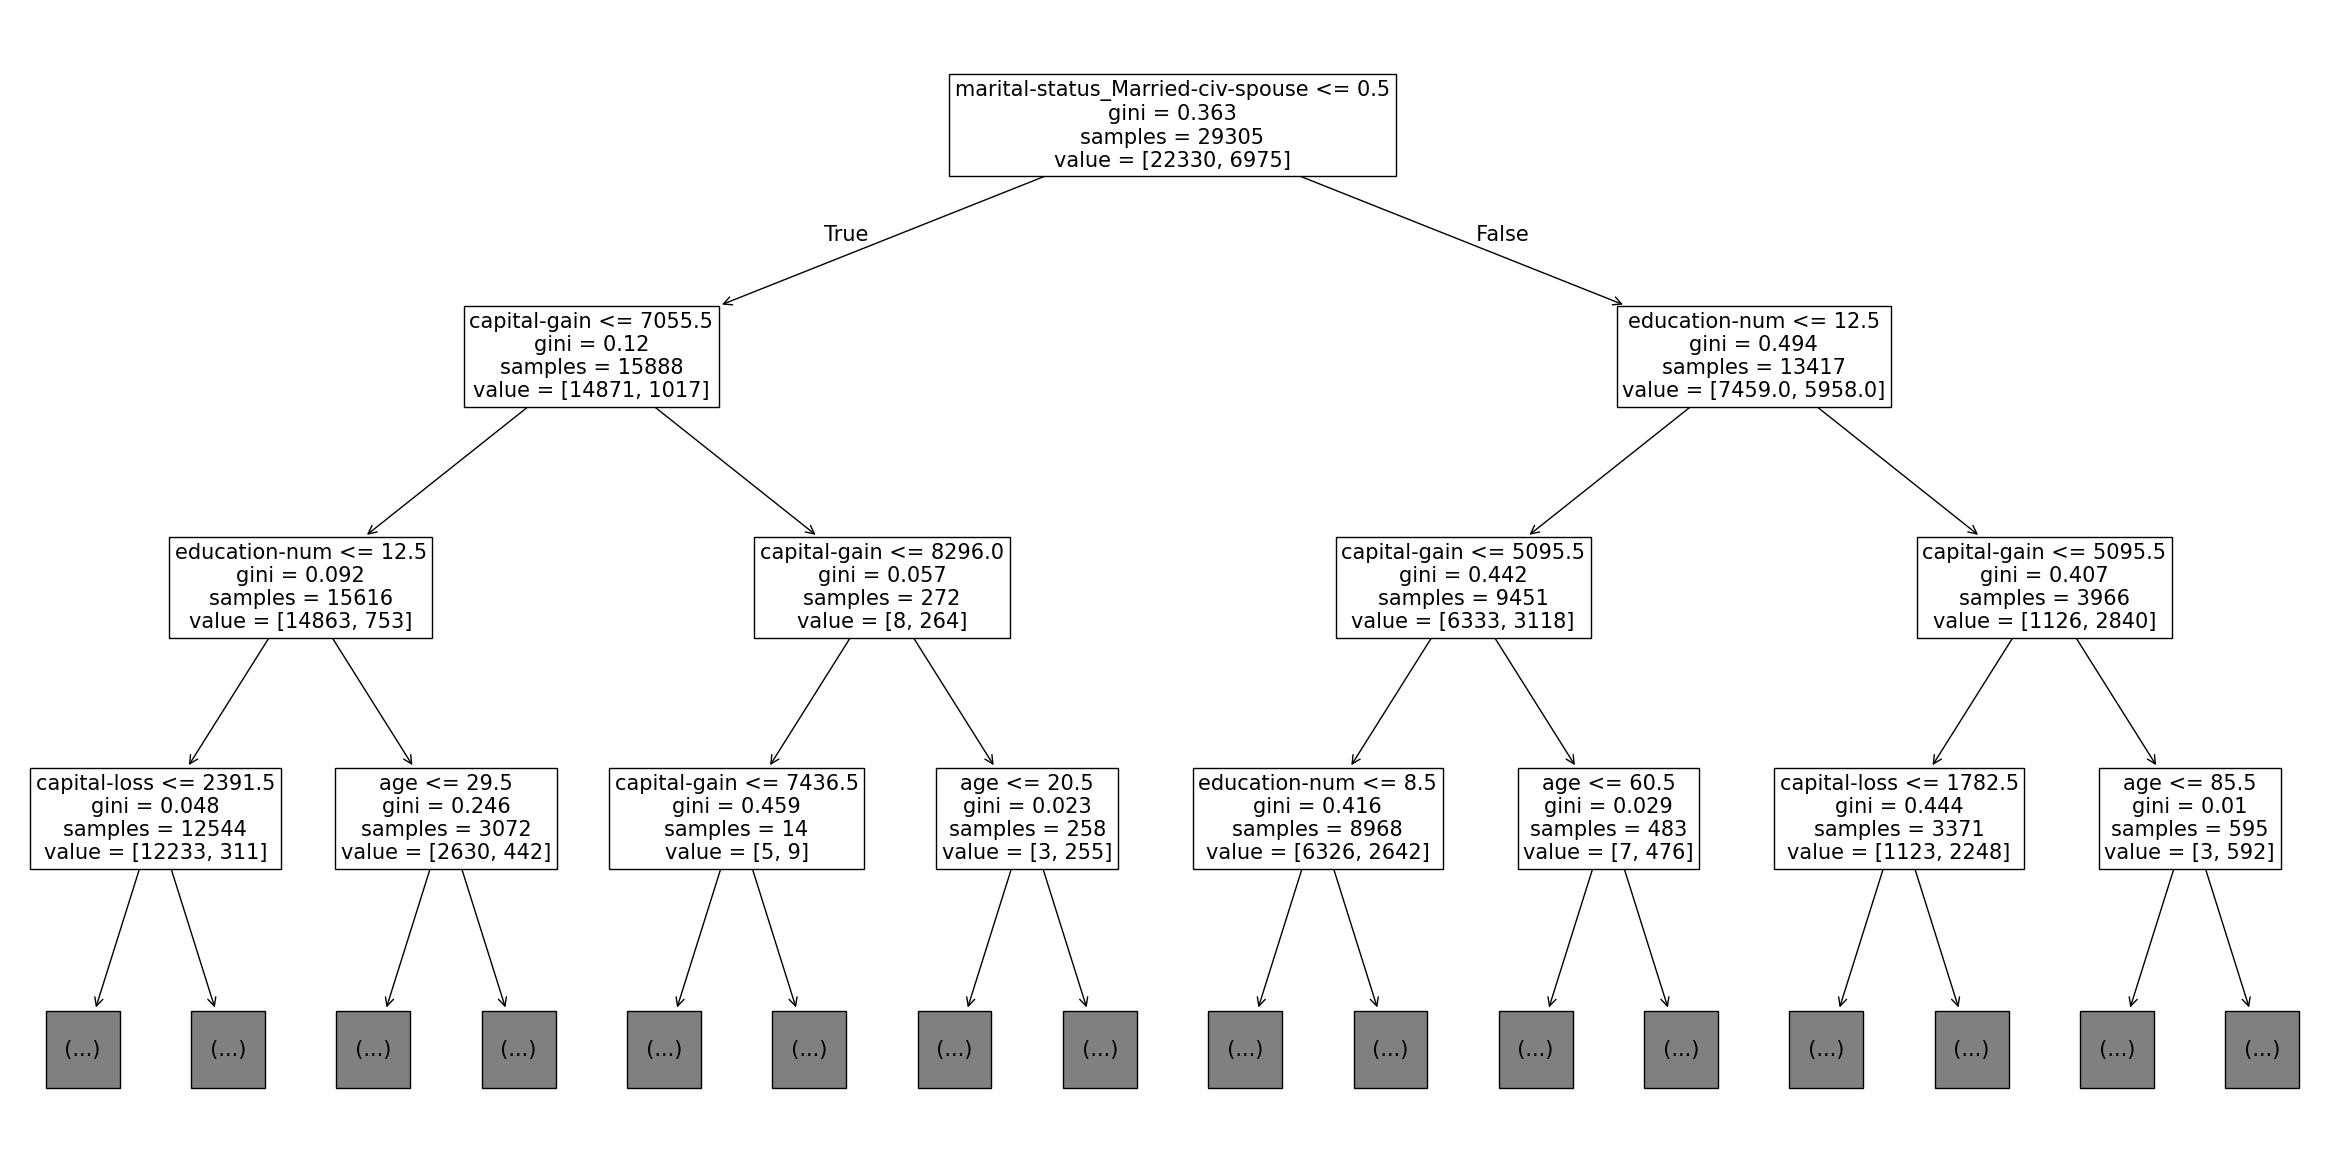

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(30, 15))
plot_tree(model, max_depth=3, fontsize=15, feature_names=X_train.columns)